In [70]:
import sys,os
from pathlib import Path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import importlib
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


import books
import functions1 as f1
import functions2 as f2
import config

plt.style.use('dark_background')

In [ ]:

ticker='GBPCHF.FOREX'
start='2025-4-10'
end='2025-10-26'
s =f1.fetch_csv_robust(ticker, params=config.params)
s=f1.sort_cols(s)
s=f2.trim_series(s, start, end)
# plt.plot(s.index, s.values)
# # give plot a title
# plt.title(f'Standardized prices for {ticker} from {start} to {end}')
# plt.show()
x_rets = np.log(s / s.shift(1)).dropna()

total_return=(s.iloc[-1]/s.iloc[0])-1
total_return = -total_return
# slope=(s.iloc[-1]-s.iloc[0])/lens
print('total return on single held short ex carry',round(total_return, 2))
# print('slope',slope)
logp = np.log(s).dropna()


sort_cols: ohlc not set. True only needd for ATR calculations for vol stops. Defaulting to False
total return on short 0.01


In [ ]:
# index = np.arange(len(logp), dtype=float)
# lr = linregress(index, logp.values)  # slope, intercept, r, p, stderr
# t_price = lr.slope / lr.stderr if lr.stderr else np.nan
# mu_day = lr.slope                 # approx daily drift in log terms
# mu_ann = mu_day * 252

# print(f"log-price t-stat: {t_price:.2f}, R2={lr.rvalue**2:.3f}, mu_day={mu_day:.6f}, mu_ann≈{mu_ann:.3f}")

# # Fitted log trend -> back to price space for plotting
# yhat_log = lr.intercept + lr.slope * index
# yhat = np.exp(yhat_log)
# yhat = pd.Series(yhat, index=logp.index)
# # get t-stat
# s_t=lr.slope / lr.stderr if lr.stderr else np.nan
# print(f"t-stat={s_t:.2f}")


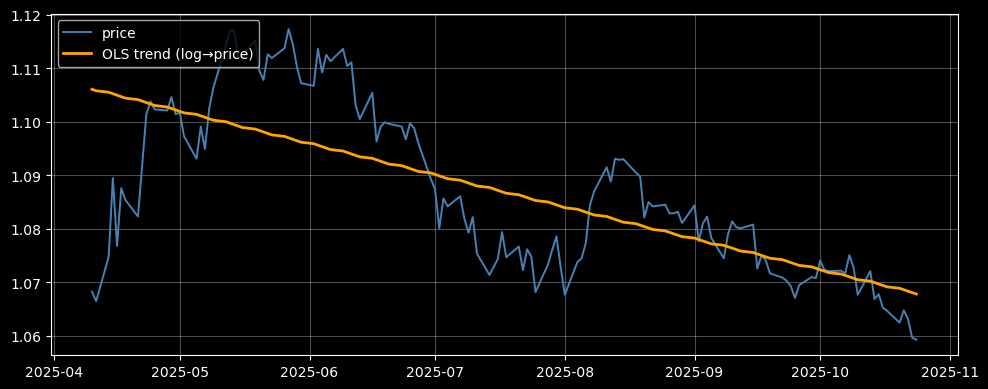

In [104]:

# Plot actual price vs fitted trend
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(s.index, s.values, label='price', color='steelblue', lw=1.4)
ax.plot(yhat.index, yhat.values, label='OLS trend (log→price)', color='orange', lw=2.0)
ax.legend(loc='upper left'); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Plotting rolling t-stat with price
- Purpose: see trend strength (t-stat of log-price slope) next to the price while keeping readable scales.
- Approach: plot price on the left y-axis, rolling t-stat on the right y-axis, add threshold lines and shade when the gate is ON.
- Notes:
  - Uses calendar-time regression inside the rolling t-stat so the trend line corresponds to actual day spacing.
  - Hysteresis gate: ON when t ≥ t_in, OFF when t ≤ t_out; shaded regions show ON periods.
  - If you prefer a single axis, you can scale/shift t-stat to sit below price; twin axes keep units honest.

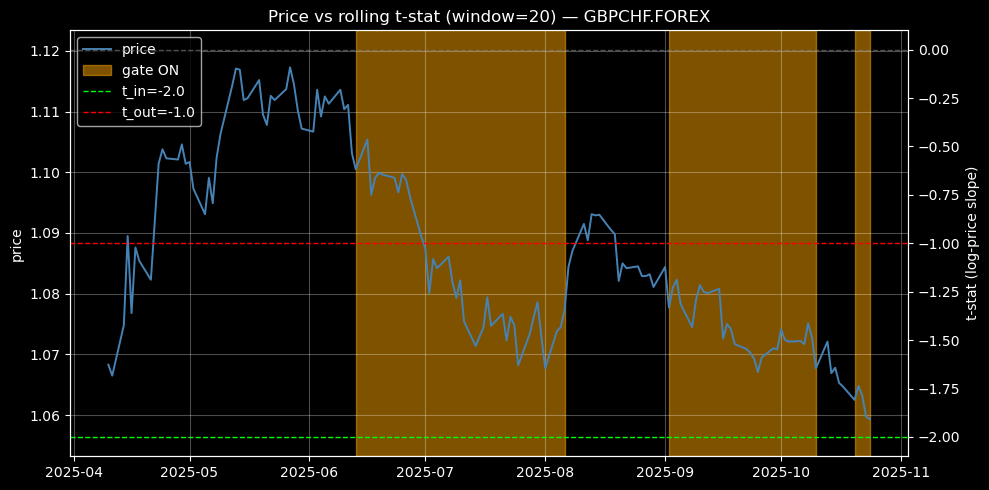

In [ ]:
# Rolling t-stat vs price with twin axes and gate shading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress

# Ensure we have price series s and logp
if 's' not in locals():
    raise RuntimeError("Price series 's' is not defined; run the earlier data cell first.")
logp = np.log(s).dropna() if 'logp' not in locals() else logp.dropna()

# --- Parameters ---
window = 20          # rolling window (trading days)
t_in, t_out = -2.0, -1.0  # hysteresis thresholds (enter ≥ t_in, exit ≤ t_out)

def rolling_t_price(logp: pd.Series, window: int) -> pd.Series:
    """Rolling t-stat of log-price slope vs calendar time (numeric dates)."""
    idx = logp.index
    tnum = mdates.date2num(idx.to_pydatetime()).astype(float)
    y = logp.values
    tstat = np.full(len(y), np.nan)
    for i in range(window - 1, len(y)):
        sl = slice(i - window + 1, i + 1)
        lr = linregress(tnum[sl], y[sl])
        tstat[i] = lr.slope / lr.stderr if lr.stderr else np.nan
    return pd.Series(tstat, index=idx, name=f"t_win{window}")

def make_gate(ts: pd.Series, t_in: float, t_out: float) -> pd.Series:
    """Hysteresis: enter when ts >= t_in, exit when ts <= t_out."""
    state = False
    g = []
    for v in ts.values:
        if not state and v <= t_in:
            state = True
        elif state and v >= t_out:
            state = False
        g.append(state)
    return pd.Series(g, index=ts.index, name="gate")

# Compute rolling t-stat and gate
tser = rolling_t_price(logp, window)
gate = make_gate(tser, t_in=t_in, t_out=t_out)

# Align to price index for shading
gate_aligned = gate.reindex(s.index).fillna(False)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(s.index, s.values, color='steelblue', lw=1.4, label='price')
ax1.set_ylabel('price')

ax2 = ax1.twinx()
# ax2.plot(tser.index, tser.values, color='orange', lw=1.2, label=f't-stat (w={window})')
ax2.axhline(0.0, color='gray', lw=1.0, ls='--', alpha=0.6)
ax2.axhline(t_in, color='lime', lw=1.0, ls='--', label=f't_in={t_in}')
ax2.axhline(t_out, color='red', lw=1.0, ls='--', label=f't_out={t_out}')
ax2.set_ylabel('t-stat (log-price slope)')

# Shade ON regions (gate true) across full y-range using axis transform
ax1.fill_between(
    gate_aligned.index,
    0, 1,
    where=gate_aligned.values,
    color='orange', alpha=0.50,
    transform=ax1.get_xaxis_transform(),
    label='gate ON'
)

# Compose legend from both axes
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')
ax1.grid(alpha=0.3)
plt.title(f"Price vs rolling t-stat (window={window}) — {ticker}")
plt.tight_layout(); plt.show()

# Optional: scaled overlay (comment out if not needed)
# scale = (s.max() - s.min()) / 6.0
# offset = s.min() - 0.5 * scale
# t_scaled = tser.reindex(s.index).values * scale + offset
# fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(s.index, s.values, color='steelblue', lw=1.4, label='price')
# ax.plot(s.index, t_scaled, color='orange', lw=1.2, label=f't-stat scaled (w={window})')
# ax.fill_between(gate_aligned.index, 0, 1, where=gate_aligned.values, color='orange', alpha=0.10, transform=ax.get_xaxis_transform(), label='gate ON')
# ax.legend(loc='upper left'); ax.grid(alpha=0.3)
# plt.title(f"Price with scaled t-stat overlay — {ticker}")
# plt.tight_layout(); plt.show()

Backtest GBPCHF.FOREX: $10,000 short when gate ON (window=20, t_in=-2.0, t_out=-1.0)
Period: 2025-04-10 → 2025-10-24 | Days=142
Gate ON days: 72 | Flips: 5
Fees total: $5.00 | Carry total: $114.29  (bps/yr=400.0)
Final P/L: $110.35


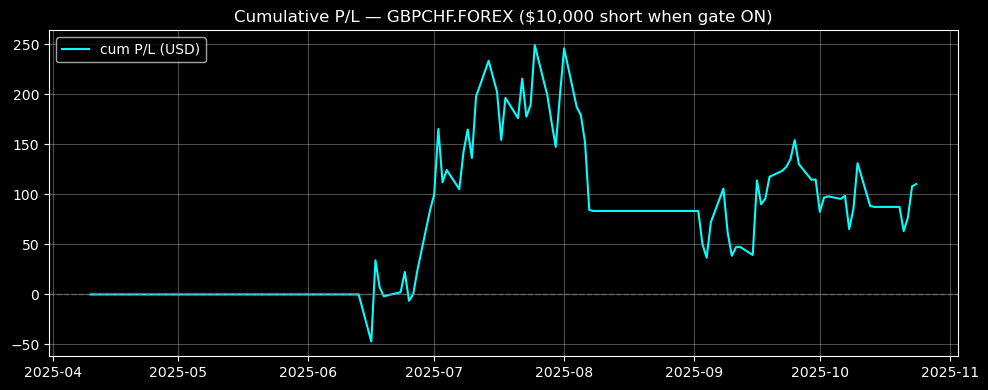

In [76]:
# Backtest: $notional short when gate ON, with fees and carry
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preconditions: need price series `s`, logp, and the gate helpers (rolling_t_price, make_gate)
assert 's' in locals() and isinstance(s, pd.Series)
assert 'logp' in locals() and isinstance(logp, pd.Series)
assert 'rolling_t_price' in globals() and 'make_gate' in globals()

# --- Parameters ---
notional_usd = 10000.0        # short USD amount when gate is ON
window = 20                   # keep consistent with your current gate
t_in, t_out = -2.0, -1.0      # downtrend-only gate thresholds
fee_per_flip_usd = 1.00       # per transition (enter or exit)
# carry sign convention: carry_bps_per_year = (r_USD - r_CHF) * 1e4.
# For short USD / long CHF, positive value here is a COST (typical when USD rates > CHF).
carry_bps_per_year = 400.0

# Rebuild gate for current settings (calendar-time t-stat)
tser = rolling_t_price(logp, window)
gate = make_gate(tser, t_in=t_in, t_out=t_out)

# Align and apply next-bar execution: position at day t follows gate decided at t-1
pos = (
    gate.reindex(s.index)
        .astype('boolean')
        .shift(1)
        .fillna(False)
        .astype(bool)
)  # True => short USD notional_usd, long CHF

# Compute log returns of price (CHF per USD)
r = np.log(s).diff()  # log return of USDCHF

# USD P/L from shorting USD against CHF (approx): -notional * r when in position
pnl_fx = (-notional_usd) * r.where(pos, 0.0)

# Transaction fees on flips (entry or exit)
flips = pos.astype(int).diff().abs().fillna(0)
pnl_fee = -fee_per_flip_usd * flips

# Daily carry (USD) when in position
carry_per_day_usd = notional_usd * (carry_bps_per_year / 10000.0) / 252.0
pnl_carry = -carry_per_day_usd * pos.astype(float)

# Total daily P/L and summary
pnl_daily = (pnl_fx.fillna(0) + pnl_fee.fillna(0) + pnl_carry.fillna(0))
cum_pnl = pnl_daily.cumsum()

n_days = len(pnl_daily)
n_on = int(pos.sum())
n_flips = int(flips.sum())
final_pnl = float(cum_pnl.iloc[-1])

print(f"Backtest {ticker}: ${notional_usd:,.0f} short when gate ON (window={window}, t_in={t_in}, t_out={t_out})")
print(f"Period: {s.index.min().date()} → {s.index.max().date()} | Days={n_days}")
print(f"Gate ON days: {n_on} | Flips: {n_flips}")
print(f"Fees total: ${-pnl_fee.sum():.2f} | Carry total: ${-pnl_carry.sum():.2f}  (bps/yr={carry_bps_per_year})")
print(f"Final P/L: ${final_pnl:.2f}")

# Optional: plot cumulative P/L
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(cum_pnl.index, cum_pnl.values, color='cyan', lw=1.5, label='cum P/L (USD)')
ax.axhline(0, color='gray', ls='--', lw=1.0, alpha=0.6)
ax.grid(alpha=0.3)
ax.legend(loc='upper left')
plt.title(f"Cumulative P/L — {ticker} (${notional_usd:,.0f} short when gate ON)")
plt.tight_layout(); plt.show()